# 05 — NLP Hazard Extraction Pipeline Test

**DESIGN.md §2B**: Validate the NLP pipeline that extracts location entities
and severity from local news headlines.

This notebook:
1. Loads a lightweight Hugging Face NER model (`dslim/bert-base-NER`)
2. Processes 5 synthetic Patna news headlines through the NER pipeline
3. Applies a keyword-based heuristic to assign `severity_score` (0.0 to 1.0)
4. Produces a summary table: Headline | Extracted Locations | Severity Score

In [19]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## 1. Load NER Pipeline

Using `dslim/bert-base-NER` — a lightweight BERT model fine-tuned on
CoNLL-2003 for named entity recognition. Runs on CPU.

In [20]:
from transformers import pipeline

ner_pipeline = pipeline(
    'ner',
    model='dslim/bert-base-NER',
    aggregation_strategy='simple',
    device=-1,
)

print(f'NER model loaded: dslim/bert-base-NER')
print(f'Device: CPU')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3226.71it/s]
[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NER model loaded: dslim/bert-base-NER
Device: CPU


## 2. Define Synthetic Patna Headlines

These headlines simulate the types of local news incidents that the
N.A.R.I hazard engine would process in production.

In [21]:
HEADLINES = [
    "Major road accident near Kankarbagh flyover in Patna leaves 3 injured",
    "Waterlogging disrupts traffic on Bailey Road after heavy rainfall",
    "Protest march blocks Fraser Road over fee hike",
    "Fire breaks out in Patna City market area, two shops gutted overnight",
    "Chain snatching reported near Gandhi Maidan, police increase night patrol in Patna",
]

## 3. Extract Named Entities

In [22]:
ner_results = []

for headline in HEADLINES:
    entities = ner_pipeline(headline)
    locations = [
        ent['word'] for ent in entities
        if ent['entity_group'] == 'LOC'
    ]
    all_entities = [
        {'word': ent['word'], 'group': ent['entity_group'], 'score': round(ent['score'], 3)}
        for ent in entities
    ]
    ner_results.append({
        'headline': headline,
        'locations': locations,
        'all_entities': all_entities,
    })

for r in ner_results:
    print(f'Headline  : {r["headline"]}')
    print(f'Locations : {r["locations"]}')
    print(f'Entities  : {r["all_entities"]}')
    print()

Headline  : Major road accident near Kankarbagh flyover in Patna leaves 3 injured
Locations : ['Kankarbagh', 'Patna']
Entities  : [{'word': 'Kankarbagh', 'group': 'LOC', 'score': np.float32(0.971)}, {'word': 'Patna', 'group': 'LOC', 'score': np.float32(0.998)}]

Headline  : Waterlogging disrupts traffic on Bailey Road after heavy rainfall
Locations : ['Bailey Road']
Entities  : [{'word': 'Bailey Road', 'group': 'LOC', 'score': np.float32(0.988)}]

Headline  : Protest march blocks Fraser Road over fee hike
Locations : ['Fraser Road']
Entities  : [{'word': 'Fraser Road', 'group': 'LOC', 'score': np.float32(0.981)}]

Headline  : Fire breaks out in Patna City market area, two shops gutted overnight
Locations : ['Patna City']
Entities  : [{'word': 'Patna City', 'group': 'LOC', 'score': np.float32(0.995)}]

Headline  : Chain snatching reported near Gandhi Maidan, police increase night patrol in Patna
Locations : ['Gandhi Maidan', 'Patna']
Entities  : [{'word': 'Gandhi Maidan', 'group': 'LOC'

## 4. Keyword-Based Severity Heuristic

Since zero-shot classification is resource-heavy for a validation notebook,
we apply a deterministic keyword heuristic to assign severity.

| Severity Tier | Keywords | Score |
|---------------|----------|-------|
| Critical | murder, killed, stabbed, bomb, dead | 1.0 |
| High | fire, accident, robbery, snatching, assault | 0.8 |
| Medium | protest, waterlogging, flood, collapse | 0.6 |
| Low | traffic, disruption, delay, roadblock | 0.4 |
| Minimal | patrol, awareness, drill, advisory | 0.2 |

In [23]:
SEVERITY_TIERS = [
    (1.0, ['murder', 'killed', 'stabbed', 'bomb', 'dead', 'death']),
    (0.8, ['fire', 'accident', 'robbery', 'snatching', 'assault', 'injured', 'gutted']),
    (0.6, ['protest', 'waterlogging', 'flood', 'collapse', 'blocked', 'blocks']),
    (0.4, ['traffic', 'disruption', 'delay', 'roadblock', 'disrupts']),
    (0.2, ['patrol', 'awareness', 'drill', 'advisory']),
]


def compute_severity(headline: str) -> float:
    """Assign severity score based on keyword matching. Returns the highest matching tier."""
    text_lower = headline.lower()
    for score, keywords in SEVERITY_TIERS:
        if any(kw in text_lower for kw in keywords):
            return score
    return 0.1  # baseline for unclassified content


for r in ner_results:
    r['severity_score'] = compute_severity(r['headline'])

## 5. Summary Table

In [24]:
summary = pd.DataFrame([
    {
        'Headline': r['headline'],
        'Extracted Locations': ', '.join(r['locations']) if r['locations'] else '(none)',
        'Severity Score': r['severity_score'],
    }
    for r in ner_results
])

summary.style.background_gradient(
    subset=['Severity Score'],
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
).format({'Severity Score': '{:.1f}'})

,Headline,Extracted Locations,Severity Score
0,Major road accident near Kankarbagh flyover in Patna leaves 3 injured,"Kankarbagh, Patna",0.8
1,Waterlogging disrupts traffic on Bailey Road after heavy rainfall,Bailey Road,0.6
2,Protest march blocks Fraser Road over fee hike,Fraser Road,0.6
3,"Fire breaks out in Patna City market area, two shops gutted overnight",Patna City,0.8
4,"Chain snatching reported near Gandhi Maidan, police increase night patrol in Patna","Gandhi Maidan, Patna",0.8


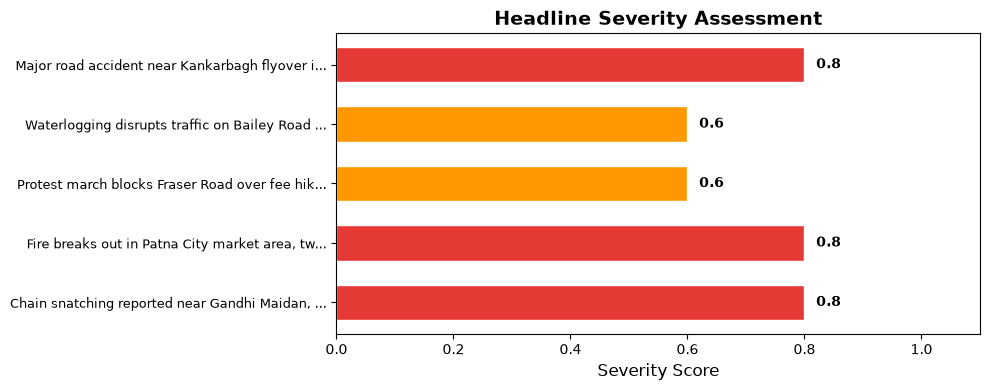

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

bar_colors = ['#E53935' if s >= 0.8 else '#FF9800' if s >= 0.6 else '#FDD835' for s in summary['Severity Score']]
short_labels = [h[:45] + '...' if len(h) > 45 else h for h in summary['Headline']]

bars = ax.barh(range(len(summary)), summary['Severity Score'], color=bar_colors, edgecolor='white', height=0.6)
ax.set_yticks(range(len(summary)))
ax.set_yticklabels(short_labels, fontsize=9)
ax.set_xlabel('Severity Score', fontsize=12)
ax.set_title('Headline Severity Assessment', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.invert_yaxis()

for bar, score in zip(bars, summary['Severity Score']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{score:.1f}',
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Entity Detail View

Full entity breakdown per headline, including non-location entities
(ORG, PER) to verify the NER model is parsing correctly.

In [26]:
entity_rows = []
for r in ner_results:
    for ent in r['all_entities']:
        entity_rows.append({
            'Headline': r['headline'][:50] + '...',
            'Entity': ent['word'],
            'Type': ent['group'],
            'Confidence': ent['score'],
        })

df_entities = pd.DataFrame(entity_rows)
if not df_entities.empty:
    df_entities.style.background_gradient(
        subset=['Confidence'], cmap='Greens', vmin=0.5, vmax=1.0
    ).format({'Confidence': '{:.3f}'})
else:
    print('No entities extracted.')

df_entities

,Headline,Entity,Type,Confidence
0,Major road accident near Kankarbagh flyover in...,Kankarbagh,LOC,0.971
1,Major road accident near Kankarbagh flyover in...,Patna,LOC,0.998
2,Waterlogging disrupts traffic on Bailey Road a...,Bailey Road,LOC,0.988
3,Protest march blocks Fraser Road over fee hike...,Fraser Road,LOC,0.981
4,"Fire breaks out in Patna City market area, two...",Patna City,LOC,0.995
5,"Chain snatching reported near Gandhi Maidan, p...",Gandhi Maidan,LOC,0.993
6,"Chain snatching reported near Gandhi Maidan, p...",Patna,LOC,0.987


In [27]:
print('=' * 60)
print('  NLP HAZARD PIPELINE TEST COMPLETE')
print('=' * 60)
print(f'  NER model         : dslim/bert-base-NER')
print(f'  Headlines tested  : {len(HEADLINES)}')
total_locs = sum(len(r['locations']) for r in ner_results)
print(f'  Locations found   : {total_locs}')
print(f'  Severity method   : Keyword heuristic (5 tiers)')
print(f'  Severity range    : [{min(r["severity_score"] for r in ner_results):.1f}, {max(r["severity_score"] for r in ner_results):.1f}]')
print('=' * 60)

  NLP HAZARD PIPELINE TEST COMPLETE
  NER model         : dslim/bert-base-NER
  Headlines tested  : 5
  Locations found   : 7
  Severity method   : Keyword heuristic (5 tiers)
  Severity range    : [0.6, 0.8]
